<a href="https://colab.research.google.com/github/Thilina93Gunasekara/it5437_assignment_02_258774L/blob/main/IT5437_A02_Q1_Line_Fitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT5437 Assignment 02 - Q1: Line Fitting
**258774L - M.L.D.T.D.U. GUNASEKARA**

This notebook implements:
- **Q1(a):** Total Least Squares (TLS) line fitting on Line 1 data
- **Q1(b):** Iterative RANSAC to recover all three lines from mixed data


## Setup — Upload `lines.csv`

In [2]:
# Cell 1: Install libraries and upload data
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload lines.csv
print("Please upload lines.csv")
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f"Uploaded: {csv_name}")


Please upload lines.csv


Saving lines.csv to lines.csv
Uploaded: lines.csv


## Q1(a) — Total Least Squares: Line 1 Only

  Q1(a) — TLS Results for Line 1
  Normal vector  : a = 0.773562
                   b = -0.633721
  Offset         : c = -3.794192
  Line equation  : 0.7736x + -0.6337y + -3.7942 = 0
  Slope-intercept: y = 1.2207x + (-5.9872)


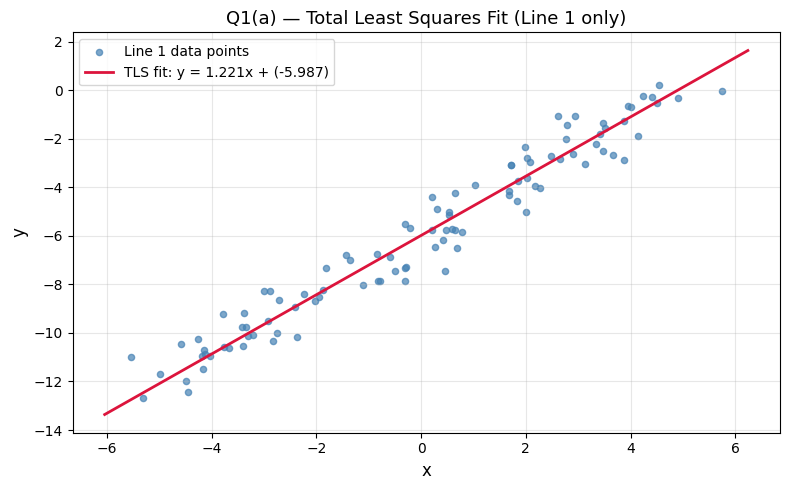

In [3]:
# Cell 2: Q1(a) — Total Least Squares
# TLS fits a line ax + by + c = 0 (with a²+b²=1) by minimising
# PERPENDICULAR distances — correct when both x and y have noise.

# Load data
D = np.genfromtxt(csv_name, delimiter=",", skip_header=1)

X_cols = D[:, :3]   # columns 0,1,2 → x1, x2, x3
Y_cols = D[:, 3:]   # columns 3,4,5 → y1, y2, y3

# Extract ONLY Line 1 data (x1, y1) as specified in Q1(a)
x1 = X_cols[:, 0]
y1 = Y_cols[:, 0]

# TLS via SVD
# Step 1: Compute centroid
x_mean = np.mean(x1)
y_mean = np.mean(y1)

# Step 2: Centre the data
A = np.column_stack([x1 - x_mean, y1 - y_mean])  # shape (100, 2)

# Step 3: SVD — last right singular vector = line normal
_, _, Vt = np.linalg.svd(A)
a, b = Vt[-1]     # normal vector [a, b]

# Step 4: Recover offset c from centroid
c = -(a * x_mean + b * y_mean)

# Slope-intercept form for reporting
slope     = -a / b
intercept = -c / b

print("=" * 50)
print("  Q1(a) — TLS Results for Line 1")
print("=" * 50)
print(f"  Normal vector  : a = {a:.6f}")
print(f"                   b = {b:.6f}")
print(f"  Offset         : c = {c:.6f}")
print(f"  Line equation  : {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
print(f"  Slope-intercept: y = {slope:.4f}x + ({intercept:.4f})")
print("=" * 50)

# Visualise
x_plot = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 300)
y_plot = slope * x_plot + intercept

plt.figure(figsize=(8, 5))
plt.scatter(x1, y1, color='steelblue', s=20, alpha=0.7, label='Line 1 data points')
plt.plot(x_plot, y_plot, color='crimson', linewidth=2,
         label=f'TLS fit: y = {slope:.3f}x + ({intercept:.3f})')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Q1(a) — Total Least Squares Fit (Line 1 only)', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls.png', dpi=150)
plt.show()


## Q1(b) — Iterative RANSAC: Recover All Three Lines


RANSAC iteration 1 — Points remaining: 300
  Line equation : 0.4512x + 0.8924y + -1.9458 = 0
  Slope-intercept: y = -0.5056x + (2.1804)
  Inliers: 82 / 300

RANSAC iteration 2 — Points remaining: 218
  Line equation : 0.7191x + -0.6949y + 0.7287 = 0
  Slope-intercept: y = 1.0348x + (1.0486)
  Inliers: 67 / 218

RANSAC iteration 3 — Points remaining: 151
  Line equation : -0.7955x + 0.6060y + 3.5787 = 0
  Slope-intercept: y = 1.3126x + (-5.9053)
  Inliers: 64 / 151

  RANSAC Results Summary — All Three Lines
  Line               a         b         c    Slope m  Intercept k
-----------------------------------------------------------------
  Line 1        0.4512    0.8924   -1.9458    -0.5056       2.1804
  Line 2        0.7191   -0.6949    0.7287     1.0348       1.0486
  Line 3       -0.7955    0.6060    3.5787     1.3126      -5.9053


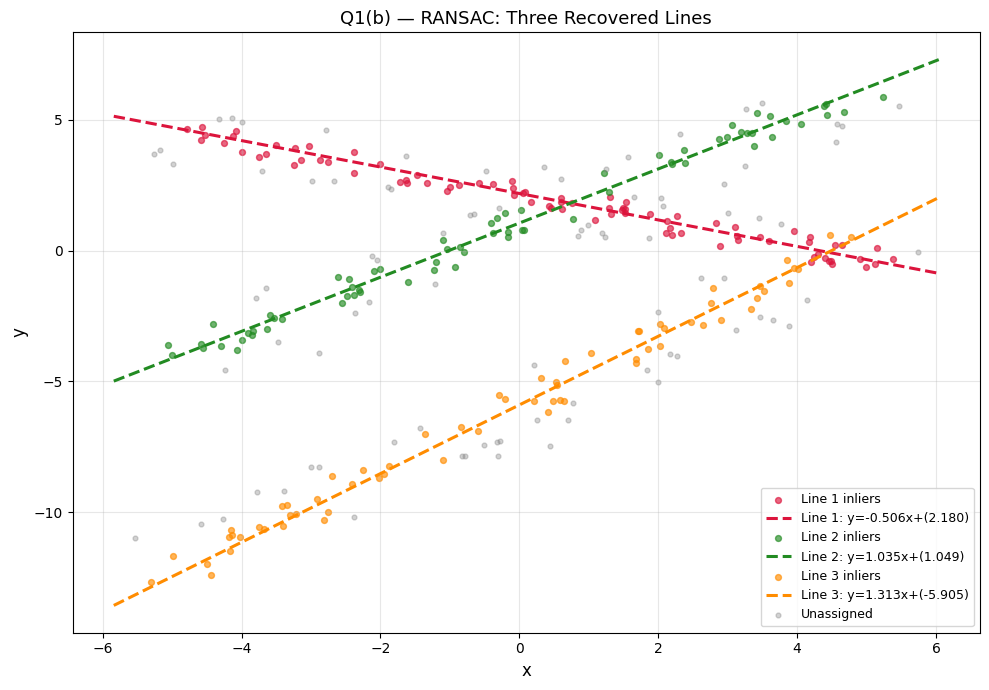

In [4]:
# Cell 3: Q1(b) — Iterative RANSAC
# RANSAC finds one line at a time, then masks (removes) its inliers
# and repeats — recovering all 3 lines from the mixed 300-point set.

# Helper: TLS fit for any set of points
def fit_line_tls(pts):
    """Fit ax + by + c = 0 via SVD. Returns (a, b, c) with a²+b²=1."""
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    A = pts - np.array([cx, cy])
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1]
    c = -(a * cx + b * cy)
    return a, b, c

# Helper: perpendicular distance from points to line
def perp_dist(pts, a, b, c):
    """Perpendicular distance of each point to line ax+by+c=0."""
    return np.abs(a * pts[:, 0] + b * pts[:, 1] + c) / np.sqrt(a**2 + b**2)

# RANSAC for one line
def ransac_line(pts, n_iter=2000, threshold=0.5, min_inliers=20):
    """
    Fit a line to pts using RANSAC.
    Returns: (a, b, c), inlier_boolean_mask
    """
    best_count = 0
    best_line  = None
    best_mask  = None
    n = len(pts)

    for _ in range(n_iter):
        # Randomly sample 2 points (minimum to define a line)
        idx = np.random.choice(n, 2, replace=False)
        try:
            a, b, c = fit_line_tls(pts[idx])
        except Exception:
            continue

        # Count inliers within perpendicular distance threshold
        dists = perp_dist(pts, a, b, c)
        mask  = dists < threshold
        count = mask.sum()

        if count > best_count and count >= min_inliers:
            best_count = count
            best_line  = (a, b, c)
            best_mask  = mask

    # Refit using ALL inliers for better accuracy
    if best_mask is not None and best_mask.sum() >= 2:
        a, b, c = fit_line_tls(pts[best_mask])
        best_line = (a, b, c)
        best_mask = perp_dist(pts, a, b, c) < threshold

    return best_line, best_mask

# Flatten all data: 300 points total
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()
all_pts = np.column_stack([X_all, Y_all])

# Iterative RANSAC: find 3 lines one by one
np.random.seed(42)   # for reproducibility

remaining_pts = all_pts.copy()
remaining_idx = np.arange(len(all_pts))
lines  = []
masks  = []
colors = ['crimson', 'forestgreen', 'darkorange']
labels = ['Line 1', 'Line 2', 'Line 3']

for i in range(3):
    print(f"\nRANSAC iteration {i+1} — Points remaining: {len(remaining_pts)}")
    line, mask = ransac_line(remaining_pts)

    if line is None:
        print("  WARNING: RANSAC failed — try increasing n_iter or adjusting threshold")
        break

    a, b, c  = line
    slope_i  = -a / b
    interc_i = -c / b
    print(f"  Line equation : {a:.4f}x + {b:.4f}y + {c:.4f} = 0")
    print(f"  Slope-intercept: y = {slope_i:.4f}x + ({interc_i:.4f})")
    print(f"  Inliers: {mask.sum()} / {len(remaining_pts)}")

    # Record in global index space
    global_mask = np.zeros(len(all_pts), dtype=bool)
    global_mask[remaining_idx[mask]] = True
    lines.append(line)
    masks.append(global_mask)

    # Remove inliers before next iteration (masking the consensus)
    remaining_idx = remaining_idx[~mask]
    remaining_pts = all_pts[remaining_idx]

# Summary table
print("\n" + "="*65)
print("  RANSAC Results Summary — All Three Lines")
print("="*65)
print(f"  {'Line':<10} {'a':>9} {'b':>9} {'c':>9} {'Slope m':>10} {'Intercept k':>12}")
print("-"*65)
for i, line in enumerate(lines):
    a, b, c = line
    m = -a/b;  k = -c/b
    print(f"  {labels[i]:<10} {a:>9.4f} {b:>9.4f} {c:>9.4f} {m:>10.4f} {k:>12.4f}")
print("="*65)

# Visualise
fig, ax = plt.subplots(figsize=(10, 7))
x_range = np.linspace(all_pts[:,0].min()-0.3, all_pts[:,0].max()+0.3, 400)

for i, (line, mask) in enumerate(zip(lines, masks)):
    a, b, c = line
    m = -a/b;  k = -c/b
    ax.scatter(all_pts[mask, 0], all_pts[mask, 1],
               color=colors[i], s=18, alpha=0.65,
               label=f'{labels[i]} inliers')
    ax.plot(x_range, m * x_range + k,
            color=colors[i], linewidth=2.2, linestyle='--',
            label=f'{labels[i]}: y={m:.3f}x+({k:.3f})')

all_assigned = np.any(np.column_stack(masks), axis=1)
if (~all_assigned).sum() > 0:
    ax.scatter(all_pts[~all_assigned, 0], all_pts[~all_assigned, 1],
               color='grey', s=12, alpha=0.35, label='Unassigned')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Q1(b) — RANSAC: Three Recovered Lines', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac.png', dpi=150)
plt.show()
